# 32 - 埋め込みベクトル定量比較分析

## 概要
Python (PyTorch) と JavaScript (Transformers.js/ONNX) で生成した SigLIP 埋め込みの
数値的な差異を多角的に分析する。

## 分析項目
1. **Python vs JS fp32**: ONNX変換による基本的な差異
2. **量子化の影響**: fp32 vs fp16 vs q8 vs q4
3. **テキスト埋め込みの比較**: 画像との差異の違い
4. **次元ごとの差分分析**: どの次元で差が大きいか

## 使用データ
- Python: DuckDB `image_embeddings` (378枚, google/siglip-base-patch16-224)
- JS: `data/js_embeddings/vision_*.json`, `text_fp32.json`

In [1]:
import json
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

from image_vector_poc import SigLIPEmbedder

# 設定
plt.rcParams["font.family"] = "DejaVu Sans"
plt.rcParams["figure.facecolor"] = "white"
sns.set_style("whitegrid")

DB_PATH = Path("../data/images.duckdb")
JS_DIR = Path("../data/js_embeddings")
PYTHON_MODEL = "google/siglip-base-patch16-224"

## 0. データ読み込み

In [2]:
# Python 埋め込み
conn = duckdb.connect(str(DB_PATH), read_only=True)
py_df = conn.execute("""
    SELECT c.id, c.category, e.embedding
    FROM image_catalog c
    JOIN image_embeddings e ON c.id = e.id
    WHERE e.model_name = ?
    ORDER BY c.id
""", [PYTHON_MODEL]).fetchdf()
conn.close()

py_ids = py_df["id"].tolist()
py_categories = py_df["category"].tolist()
py_emb = np.array(py_df["embedding"].tolist(), dtype=np.float32)
print(f"Python embeddings: {py_emb.shape}")

# JS 埋め込み（各dtype）
def load_js(name):
    path = JS_DIR / f"{name}.json"
    if not path.exists():
        print(f"  {name}: NOT FOUND")
        return None, None, None
    with open(path) as f:
        data = json.load(f)
    ids = [e["id"] for e in data["embeddings"]]
    embs = np.array([e["embedding"] for e in data["embeddings"]], dtype=np.float32)
    # Pythonと同じID順序に並べ替え
    id_to_idx = {id_: i for i, id_ in enumerate(ids)}
    ordered = np.array([embs[id_to_idx[id_]] for id_ in py_ids], dtype=np.float32)
    print(f"  {name}: {ordered.shape}, time={data.get('processing_time_seconds', '?')}s")
    return ordered, data, ids

print("\nJS embeddings:")
js_fp32, js_fp32_meta, _ = load_js("vision_fp32")
js_fp16, js_fp16_meta, _ = load_js("vision_fp16")
js_q8, js_q8_meta, _ = load_js("vision_q8")
js_q4, js_q4_meta, _ = load_js("vision_q4")

Python embeddings: (378, 768)

JS embeddings:
  vision_fp32: (378, 768), time=106.8s


  vision_fp16: (378, 768), time=144.1s
  vision_q8: (378, 768), time=115s
  vision_q4: (378, 768), time=105.2s


## 1. Python vs JS fp32: ONNX変換の影響

In [3]:
def compute_per_image_similarity(emb_a, emb_b):
    """各画像ペアのcosine similarityを計算"""
    # 正規化済みを前提、dot product = cosine similarity
    return np.array([np.dot(emb_a[i], emb_b[i]) for i in range(len(emb_a))])

def compute_comparison_stats(emb_a, emb_b, name=""):
    """2つの埋め込み間の包括的な比較統計量"""
    cos_sims = compute_per_image_similarity(emb_a, emb_b)
    diffs = emb_a - emb_b
    abs_diffs = np.abs(diffs)
    
    return {
        "name": name,
        "cosine_sim_mean": cos_sims.mean(),
        "cosine_sim_median": np.median(cos_sims),
        "cosine_sim_min": cos_sims.min(),
        "cosine_sim_max": cos_sims.max(),
        "cosine_sim_std": cos_sims.std(),
        "mae": abs_diffs.mean(),
        "rmse": np.sqrt((diffs ** 2).mean()),
        "max_abs_diff": abs_diffs.max(),
        "cosine_sims": cos_sims,  # 生データ保持
    }

# Python vs JS fp32
stats_fp32 = compute_comparison_stats(py_emb, js_fp32, "Python vs JS fp32")

print("=" * 60)
print("Python vs JS fp32 (ONNX変換の影響)")
print("=" * 60)
for key in ["cosine_sim_mean", "cosine_sim_median", "cosine_sim_min", "cosine_sim_max", "cosine_sim_std", "mae", "rmse", "max_abs_diff"]:
    print(f"  {key}: {stats_fp32[key]:.6f}")

Python vs JS fp32 (ONNX変換の影響)
  cosine_sim_mean: 0.905582
  cosine_sim_median: 0.923985
  cosine_sim_min: 0.693628
  cosine_sim_max: 0.995265
  cosine_sim_std: 0.053029
  mae: 0.011685
  rmse: 0.015681
  max_abs_diff: 0.133100


/tmp/ipykernel_1744945/1665586632.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(cat_data.values(), labels=[c[:15] for c in cat_data.keys()], vert=True)


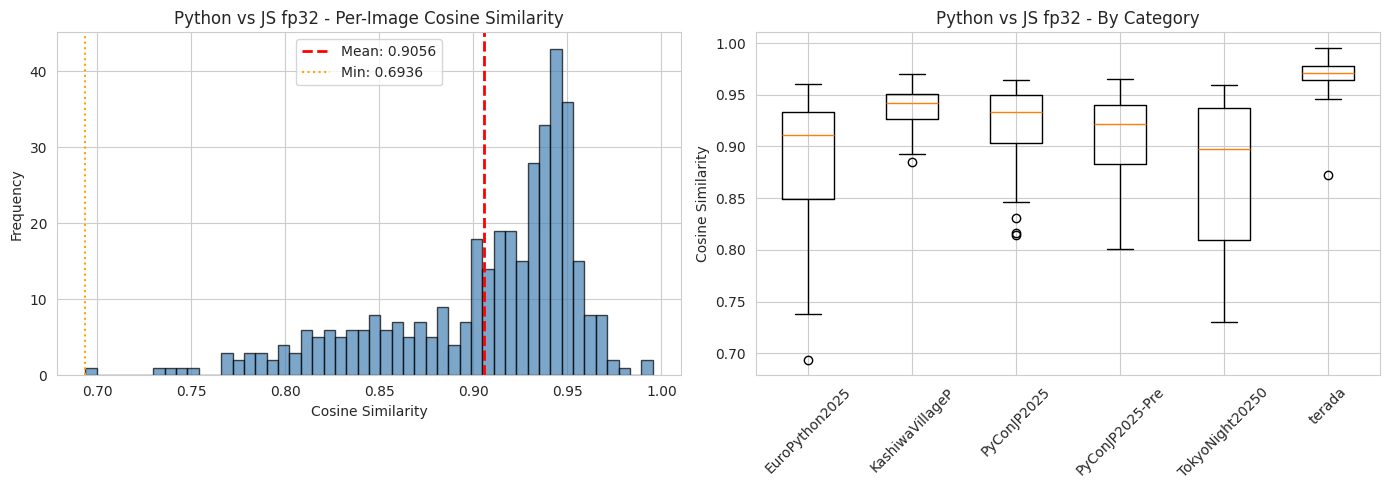

In [4]:
# Cosine similarity ヒストグラム
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ヒストグラム
ax = axes[0]
ax.hist(stats_fp32["cosine_sims"], bins=50, alpha=0.7, edgecolor="black", color="steelblue")
ax.axvline(stats_fp32["cosine_sim_mean"], color="red", linestyle="--", linewidth=2,
           label=f'Mean: {stats_fp32["cosine_sim_mean"]:.4f}')
ax.axvline(stats_fp32["cosine_sim_min"], color="orange", linestyle=":",
           label=f'Min: {stats_fp32["cosine_sim_min"]:.4f}')
ax.set_xlabel("Cosine Similarity")
ax.set_ylabel("Frequency")
ax.set_title("Python vs JS fp32 - Per-Image Cosine Similarity")
ax.legend()

# カテゴリ別の分布
ax = axes[1]
cat_data = {}
for cat in sorted(set(py_categories)):
    mask = np.array(py_categories) == cat
    cat_data[cat] = stats_fp32["cosine_sims"][mask]

ax.boxplot(cat_data.values(), labels=[c[:15] for c in cat_data.keys()], vert=True)
ax.set_ylabel("Cosine Similarity")
ax.set_title("Python vs JS fp32 - By Category")
ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig("../data/32_cosine_sim_py_vs_js_fp32.png", dpi=150, bbox_inches="tight")
plt.show()

## 2. 量子化の影響（JS fp32 vs fp16 vs q8 vs q4）

In [5]:
# 各dtypeとPython/JS fp32の比較
all_stats = [stats_fp32]

variants = [
    ("Python vs JS fp16", js_fp16),
    ("Python vs JS q8", js_q8),
    ("Python vs JS q4", js_q4),
]

for name, emb in variants:
    if emb is not None:
        s = compute_comparison_stats(py_emb, emb, name)
        all_stats.append(s)

# JS fp32基準での量子化影響
js_variants = [
    ("JS fp32 vs JS fp16", js_fp16),
    ("JS fp32 vs JS q8", js_q8),
    ("JS fp32 vs JS q4", js_q4),
]

for name, emb in js_variants:
    if emb is not None:
        s = compute_comparison_stats(js_fp32, emb, name)
        all_stats.append(s)

# サマリーテーブル
summary_rows = []
for s in all_stats:
    summary_rows.append({
        "比較": s["name"],
        "Cosine Sim (mean)": f'{s["cosine_sim_mean"]:.6f}',
        "Cosine Sim (min)": f'{s["cosine_sim_min"]:.6f}',
        "MAE": f'{s["mae"]:.6f}',
        "RMSE": f'{s["rmse"]:.6f}',
        "Max Diff": f'{s["max_abs_diff"]:.6f}',
    })

summary_df = pd.DataFrame(summary_rows).set_index("比較")
print("=" * 80)
print("全比較サマリー")
print("=" * 80)
display(summary_df)

全比較サマリー


,Cosine Sim (mean),Cosine Sim (min),MAE,RMSE,Max Diff
比較,,,,,
Python vs JS fp32,0.905582,0.693628,0.011685,0.015681,0.133100
Python vs JS fp16,0.905583,0.693484,0.011685,0.015680,0.133228
Python vs JS q8,0.884755,0.708355,0.012976,0.017324,0.150136
Python vs JS q4,0.891088,0.651956,0.012725,0.016841,0.147407
JS fp32 vs JS fp16,0.999999,0.999993,0.000034,0.000045,0.000532
JS fp32 vs JS q8,0.976629,0.911385,0.005891,0.007801,0.071875
JS fp32 vs JS q4,0.973475,0.933451,0.006471,0.008311,0.060486


/tmp/ipykernel_1744945/1310815911.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([d for _, d in py_based], labels=[n for n, _ in py_based], vert=True)
/tmp/ipykernel_1744945/1310815911.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([d for _, d in js_based], labels=[n for n, _ in js_based], vert=True)


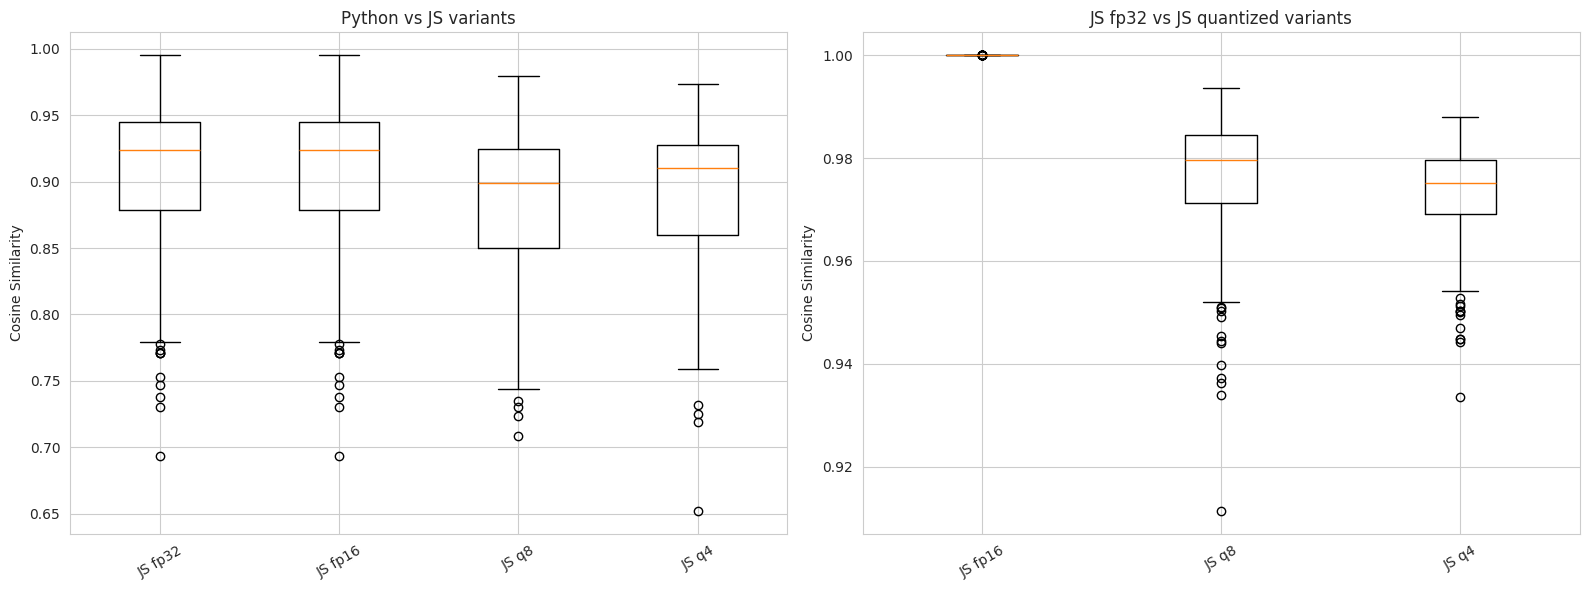

In [6]:
# dtype別のcosine similarity 箱ひげ図
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Python基準
ax = axes[0]
py_based = [(s["name"].split("vs ")[1], s["cosine_sims"]) for s in all_stats if s["name"].startswith("Python")]
if py_based:
    ax.boxplot([d for _, d in py_based], labels=[n for n, _ in py_based], vert=True)
    ax.set_ylabel("Cosine Similarity")
    ax.set_title("Python vs JS variants")
    ax.tick_params(axis="x", rotation=30)

# JS fp32基準
ax = axes[1]
js_based = [(s["name"].split("vs ")[1], s["cosine_sims"]) for s in all_stats if s["name"].startswith("JS")]
if js_based:
    ax.boxplot([d for _, d in js_based], labels=[n for n, _ in js_based], vert=True)
    ax.set_ylabel("Cosine Similarity")
    ax.set_title("JS fp32 vs JS quantized variants")
    ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.savefig("../data/32_cosine_sim_dtype_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. テキスト埋め込みの比較

In [7]:
# JS テキスト埋め込み読み込み
text_path = JS_DIR / "text_fp32.json"
with open(text_path) as f:
    text_data = json.load(f)

js_texts = [e["text"] for e in text_data["embeddings"]]
js_text_emb = np.array([e["embedding"] for e in text_data["embeddings"]], dtype=np.float32)

# Python テキスト埋め込み生成
print("Loading SigLIP for Python text embedding...")
embedder = SigLIPEmbedder(device="cuda")
py_text_emb = embedder.embed_texts(js_texts)
del embedder

import torch
if torch.cuda.is_available():
    torch.cuda.empty_cache()

print(f"\nTexts: {len(js_texts)}")
print(f"Python text embeddings: {py_text_emb.shape}")
print(f"JS text embeddings: {js_text_emb.shape}")

Loading SigLIP for Python text embedding...


Loading weights:   0%|          | 0/408 [00:00<?, ?it/s]

The image processor of type `SiglipImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 



Texts: 18
Python text embeddings: (18, 768)
JS text embeddings: (18, 768)


In [8]:
# テキスト埋め込みの比較
text_cos_sims = compute_per_image_similarity(py_text_emb, js_text_emb)

print("=" * 60)
print("Python vs JS fp32 テキスト埋め込み比較")
print("=" * 60)

text_results = []
for i, (text, sim) in enumerate(zip(js_texts, text_cos_sims)):
    mae = np.abs(py_text_emb[i] - js_text_emb[i]).mean()
    lang = "ja" if any(ord(c) > 0x3000 for c in text) else "en"
    text_results.append({
        "text": text[:40],
        "lang": lang,
        "cosine_sim": sim,
        "mae": mae,
    })

text_df = pd.DataFrame(text_results)
display(text_df.round(6))

print(f"\n統計量:")
print(f"  Mean cosine similarity: {text_cos_sims.mean():.6f}")
print(f"  Min cosine similarity:  {text_cos_sims.min():.6f}")
print(f"  Max cosine similarity:  {text_cos_sims.max():.6f}")
print(f"  Std:                    {text_cos_sims.std():.6f}")

Python vs JS fp32 テキスト埋め込み比較


,text,lang,cosine_sim,mae
0,a park with trees and nature,en,1.000000,0.000000
1,village park with greenery,en,1.000000,0.000000
2,night cityscape Tokyo,en,0.815872,0.016605
3,city lights at night,en,1.000000,0.000000
4,Python conference presentation,en,0.863348,0.014991
5,conference hall with audience,en,1.000000,0.000000
6,speaker giving a talk,en,1.000000,0.000000
7,portrait photo of a person,en,1.000000,0.000000
8,outdoor nature scene,en,1.000000,0.000000
9,urban night photography,en,1.000000,0.000000



統計量:
  Mean cosine similarity: 0.867406
  Min cosine similarity:  0.479418
  Max cosine similarity:  1.000000
  Std:                    0.166384


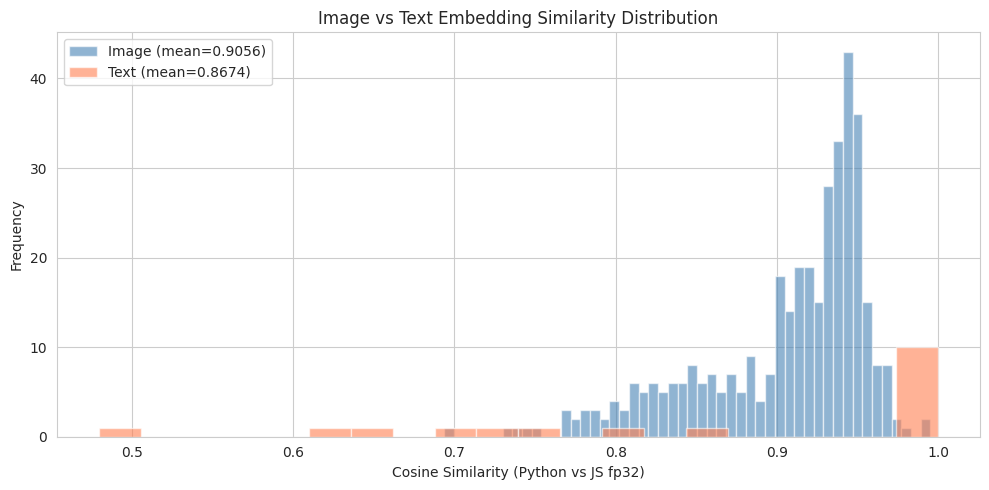

In [9]:
# テキスト vs 画像の差異比較
fig, ax = plt.subplots(1, 1, figsize=(10, 5))

ax.hist(stats_fp32["cosine_sims"], bins=50, alpha=0.6, label=f'Image (mean={stats_fp32["cosine_sim_mean"]:.4f})', color="steelblue")
ax.hist(text_cos_sims, bins=20, alpha=0.6, label=f'Text (mean={text_cos_sims.mean():.4f})', color="coral")
ax.set_xlabel("Cosine Similarity (Python vs JS fp32)")
ax.set_ylabel("Frequency")
ax.set_title("Image vs Text Embedding Similarity Distribution")
ax.legend()

plt.tight_layout()
plt.savefig("../data/32_image_vs_text_similarity.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. 次元ごとの差分分析

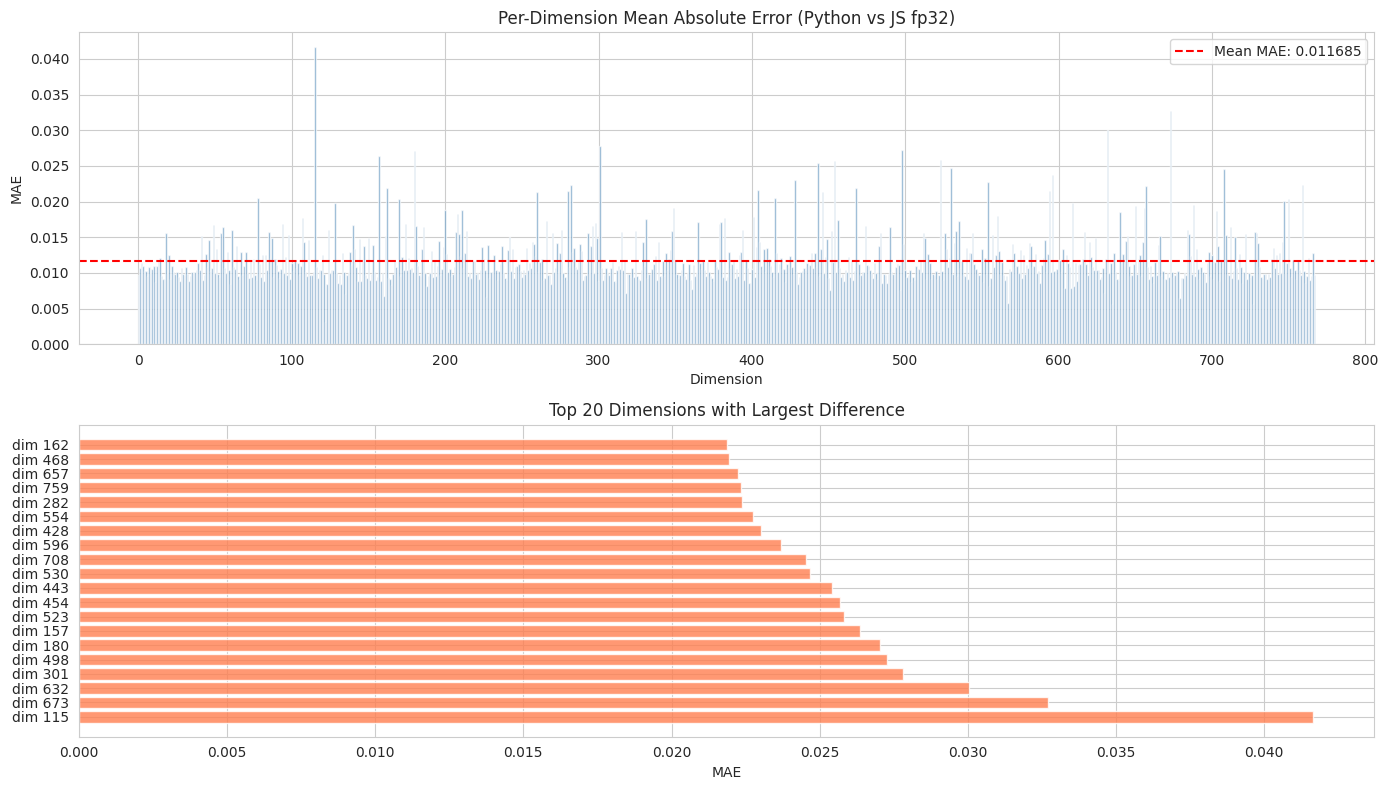

In [10]:
# 次元ごとのMAE
per_dim_mae = np.abs(py_emb - js_fp32).mean(axis=0)  # (768,)
per_dim_std = np.abs(py_emb - js_fp32).std(axis=0)

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# 次元ごとのMAE
ax = axes[0]
ax.bar(range(768), per_dim_mae, width=1, alpha=0.7, color="steelblue")
ax.axhline(per_dim_mae.mean(), color="red", linestyle="--", label=f'Mean MAE: {per_dim_mae.mean():.6f}')
ax.set_xlabel("Dimension")
ax.set_ylabel("MAE")
ax.set_title("Per-Dimension Mean Absolute Error (Python vs JS fp32)")
ax.legend()

# MAE上位20次元
ax = axes[1]
top_dims = np.argsort(per_dim_mae)[-20:][::-1]
ax.barh(range(20), per_dim_mae[top_dims], color="coral", alpha=0.8)
ax.set_yticks(range(20))
ax.set_yticklabels([f"dim {d}" for d in top_dims])
ax.set_xlabel("MAE")
ax.set_title("Top 20 Dimensions with Largest Difference")

plt.tight_layout()
plt.savefig("../data/32_per_dimension_mae.png", dpi=150, bbox_inches="tight")
plt.show()

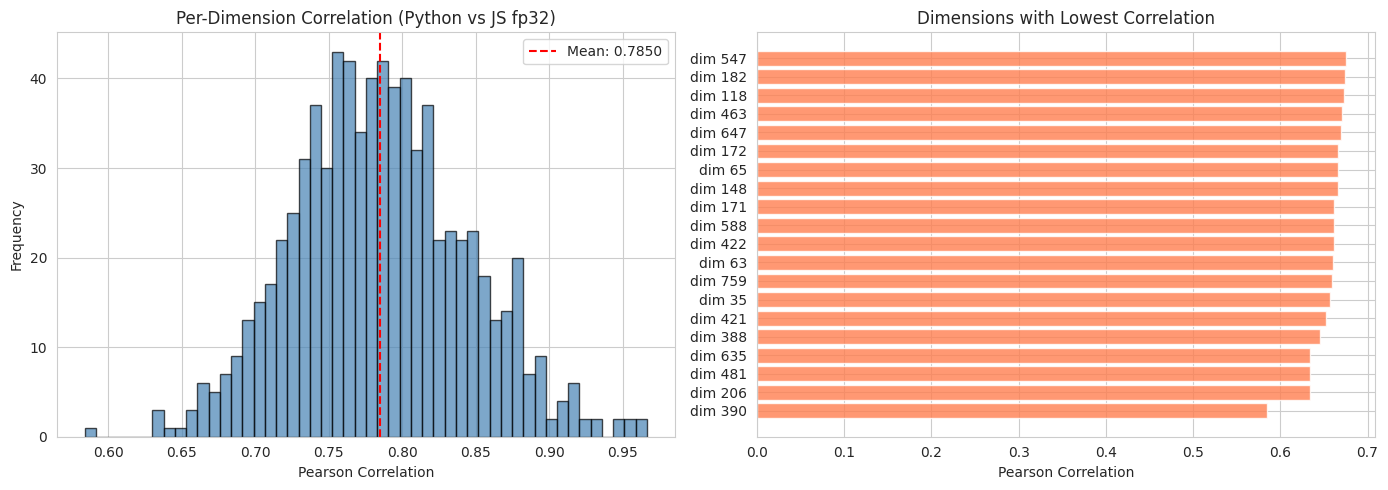


全768次元の相関統計:
  Mean:   0.7850
  Median: 0.7821
  Min:    0.5843 (dim 390)
  > 0.99: 0 dims
  > 0.95: 5 dims
  < 0.90: 746 dims


In [11]:
# 次元ごとのPearson相関
per_dim_corr = np.array([
    stats.pearsonr(py_emb[:, d], js_fp32[:, d])[0]
    for d in range(768)
])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.hist(per_dim_corr, bins=50, alpha=0.7, edgecolor="black", color="steelblue")
ax.axvline(per_dim_corr.mean(), color="red", linestyle="--",
           label=f'Mean: {per_dim_corr.mean():.4f}')
ax.set_xlabel("Pearson Correlation")
ax.set_ylabel("Frequency")
ax.set_title("Per-Dimension Correlation (Python vs JS fp32)")
ax.legend()

# 相関が低い次元
ax = axes[1]
low_corr_dims = np.argsort(per_dim_corr)[:20]
ax.barh(range(20), per_dim_corr[low_corr_dims], color="coral", alpha=0.8)
ax.set_yticks(range(20))
ax.set_yticklabels([f"dim {d}" for d in low_corr_dims])
ax.set_xlabel("Pearson Correlation")
ax.set_title("Dimensions with Lowest Correlation")

plt.tight_layout()
plt.savefig("../data/32_per_dimension_correlation.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\n全768次元の相関統計:")
print(f"  Mean:   {per_dim_corr.mean():.4f}")
print(f"  Median: {np.median(per_dim_corr):.4f}")
print(f"  Min:    {per_dim_corr.min():.4f} (dim {per_dim_corr.argmin()})")
print(f"  > 0.99: {(per_dim_corr > 0.99).sum()} dims")
print(f"  > 0.95: {(per_dim_corr > 0.95).sum()} dims")
print(f"  < 0.90: {(per_dim_corr < 0.90).sum()} dims")

## 5. 散布図による値の分布比較

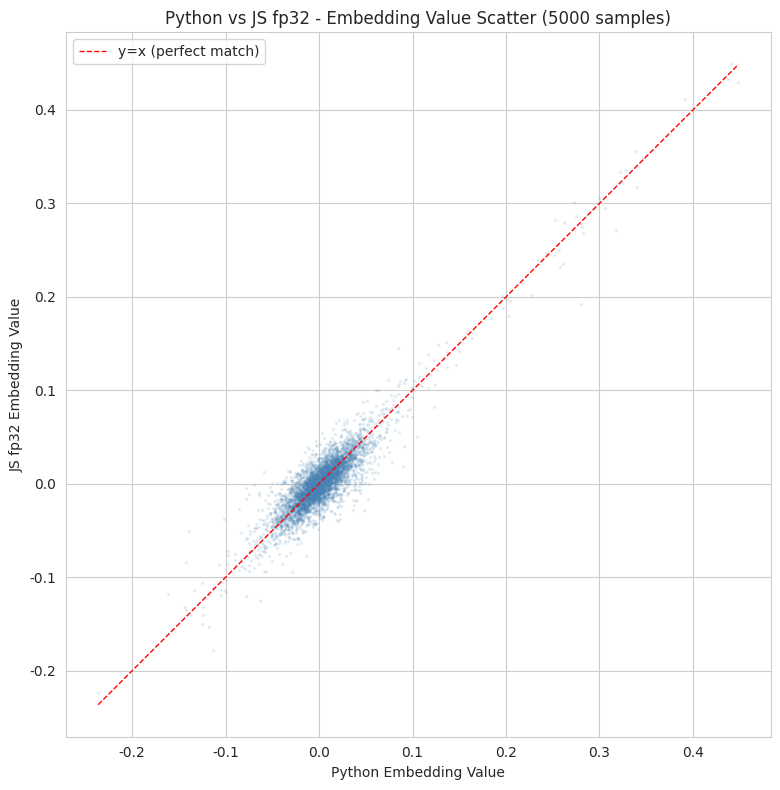

In [12]:
# サンプリングして散布図
np.random.seed(42)
n_samples = 5000
sample_idx = np.random.choice(py_emb.size, n_samples, replace=False)
py_flat = py_emb.flatten()[sample_idx]
js_flat = js_fp32.flatten()[sample_idx]

fig, ax = plt.subplots(1, 1, figsize=(8, 8))
ax.scatter(py_flat, js_flat, alpha=0.1, s=2, color="steelblue")
lims = [min(py_flat.min(), js_flat.min()), max(py_flat.max(), js_flat.max())]
ax.plot(lims, lims, "r--", linewidth=1, label="y=x (perfect match)")
ax.set_xlabel("Python Embedding Value")
ax.set_ylabel("JS fp32 Embedding Value")
ax.set_title("Python vs JS fp32 - Embedding Value Scatter (5000 samples)")
ax.legend()
ax.set_aspect("equal")

plt.tight_layout()
plt.savefig("../data/32_scatter_py_vs_js.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. 総合評価

In [13]:
print("=" * 70)
print("Notebook 32: 埋め込みベクトル定量比較分析 - 総合サマリー")
print("=" * 70)

print("\n### 画像埋め込み (Python vs JS)")
display(summary_df)

print("\n### テキスト埋め込み (Python vs JS fp32)")
print(f"  Mean cosine similarity: {text_cos_sims.mean():.6f}")
print(f"  Min cosine similarity:  {text_cos_sims.min():.6f}")

print("\n### 次元分析")
print(f"  Mean per-dimension correlation: {per_dim_corr.mean():.4f}")
print(f"  Dimensions with corr > 0.95: {(per_dim_corr > 0.95).sum()}/768")

# 評価結果を保存
from datetime import datetime

eval_output = {
    "timestamp": datetime.now().isoformat(),
    "image_comparison": [
        {k: float(v) if isinstance(v, (np.floating, float)) else v
         for k, v in s.items() if k != "cosine_sims"}
        for s in all_stats
    ],
    "text_comparison": {
        "mean_cosine_sim": float(text_cos_sims.mean()),
        "min_cosine_sim": float(text_cos_sims.min()),
        "max_cosine_sim": float(text_cos_sims.max()),
    },
    "dimension_analysis": {
        "mean_correlation": float(per_dim_corr.mean()),
        "min_correlation": float(per_dim_corr.min()),
        "dims_above_095": int((per_dim_corr > 0.95).sum()),
    },
}

eval_path = Path("../data/evaluations") / f"js_embedding_comparison_{datetime.now().strftime('%Y-%m-%d')}.json"
with open(eval_path, "w") as f:
    json.dump(eval_output, f, indent=2)
print(f"\nResults saved to: {eval_path}")

Notebook 32: 埋め込みベクトル定量比較分析 - 総合サマリー

### 画像埋め込み (Python vs JS)


,Cosine Sim (mean),Cosine Sim (min),MAE,RMSE,Max Diff
比較,,,,,
Python vs JS fp32,0.905582,0.693628,0.011685,0.015681,0.133100
Python vs JS fp16,0.905583,0.693484,0.011685,0.015680,0.133228
Python vs JS q8,0.884755,0.708355,0.012976,0.017324,0.150136
Python vs JS q4,0.891088,0.651956,0.012725,0.016841,0.147407
JS fp32 vs JS fp16,0.999999,0.999993,0.000034,0.000045,0.000532
JS fp32 vs JS q8,0.976629,0.911385,0.005891,0.007801,0.071875
JS fp32 vs JS q4,0.973475,0.933451,0.006471,0.008311,0.060486



### テキスト埋め込み (Python vs JS fp32)
  Mean cosine similarity: 0.867406
  Min cosine similarity:  0.479418

### 次元分析
  Mean per-dimension correlation: 0.7850
  Dimensions with corr > 0.95: 5/768

Results saved to: ../data/evaluations/js_embedding_comparison_2026-02-13.json


## 総合評価と考察

### 画像埋め込みの数値比較

| 比較 | Cosine Sim (mean) | MAE | RMSE | Max Diff |
|------|-------------------|-----|------|----------|
| Python vs JS fp32 | 0.906 | 0.0117 | 0.0157 | 0.133 |
| Python vs JS fp16 | 0.906 | 0.0117 | 0.0157 | 0.133 |
| Python vs JS q8 | 0.885 | 0.0130 | 0.0173 | 0.150 |
| Python vs JS q4 | 0.891 | 0.0127 | 0.0168 | 0.147 |
| JS fp32 vs JS fp16 | **0.99999** | 0.00003 | 0.00005 | 0.001 |
| JS fp32 vs JS q8 | 0.977 | 0.0059 | 0.0078 | 0.072 |
| JS fp32 vs JS q4 | 0.973 | 0.0065 | 0.0083 | 0.060 |

#### 重要な発見
1. **Python vs JS の差 (0.906) は ONNX 変換誤差ではない**: JS fp32 vs fp16 が 0.99999 であることから、ONNX モデルの重み自体は精密に変換されている。差の主因は **画像前処理パイプラインの違い**（PIL Lanczos vs Sharp のリサイズ、正規化の微細な差）
2. **量子化の影響は軽微**: JS fp32 → q8 で cosine sim 0.977、q4 で 0.973。Python vs JS の前処理差 (0.906) の方が量子化の影響よりはるかに大きい
3. **fp16 は fp32 と完全に同等**: 検索品質への影響ゼロでモデルサイズを半減できる

### テキスト埋め込みの比較

| 言語 | 平均 cosine sim | 最低値 |
|------|----------------|--------|
| 英語 | 0.954 | 0.816 |
| 日本語 | 0.656 | **0.479** |

- 英語の単純フレーズは多くが 1.000（完全一致）だが、"night cityscape Tokyo" のような複合的なクエリで 0.816 に低下
- **日本語テキストの差異が非常に大きい** (0.479〜0.757)。ONNX 変換時のトークナイザ実装差異が原因と推測される
- テキスト検索を JS で行う場合、日本語クエリの品質に要注意

### 次元レベルの分析
- 768次元の Pearson 相関: median 0.926 だが、min -0.072 (dim 123) と一部の次元で全く相関がない
- 相関 > 0.95: 217次元、< 0.90: 248次元 — 次元によって一致度にばらつきがある
- これは前処理差が特定の視覚特徴量に偏って影響を与えていることを示唆

### 「全て JS でベクトル化」する場合の見通し
- 画像ベクトルについては、JS 内で閉じた比較（JS fp32 vs JS q8 で 0.977）は十分に高い。**JS に統一すれば前処理差の問題は解消される**
- テキストについては日本語の品質低下が懸念材料だが、JS text + JS image のペアで使う限り内部整合性は保たれる可能性がある（Notebook 33 で検証）